# Machine Learning
## Project 2: Decision Trees, Ensemble Voiting Regression, and Random Forest Regression
### Adam John Holt

## Outline

The purpose of this notebook is to explore various techniques and tuning parameters for a set of Machine Learning models. Firstly, we shall train a number of decision tree classifiers with different hyperparameters on the [Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)) (diagnostic) dataset (available as part of the [Scikit-Learn](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset) library) and compare their respective performance.

Secondly, we investigate various regression models implemented within a Voting framework in order to determine the strength of concrete from a [Concrete Slump Test dataset](https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test).

Finally, using geometric and physical characteristics of abalone shells, we implement a sequence of Decision Tree and Random Forrest Regression models to predict the age of abalone via the proxy measure of the number of rings present in the shells. For this we use the [abalone dataset](https://archive.ics.uci.edu/ml/datasets/Abalone).


N.B. Some of the code (and/or techniques) presented in this notebook are adapted from the book, *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow 2nd ed. (2019) by Aurélien Géron*.

In [72]:
import sys
import warnings
import os

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore" 

## Decision Tree Classification of  Breast Cancer Wisconsin (diagnostic) Data

### 1.

Here we load the Breast Cancer diagnostic data. Additionally, frequently used library modules will be imported for later use. Further functionality needed from additional modules will be imported when required.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True, as_frame=True)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

We can see a range of numeric features related to the geometric and physical characteristics of the breast cancer diagnostic data. Now we shall begin a rudimentary exploration of these data.

### 2.

With our data loaded we can begin our investigation by visualizing correlations between features. This enables us to determine if it may be suitable to remove certain features due to very strong linear relationships (i.e., ameliorate potential multicollinearity).

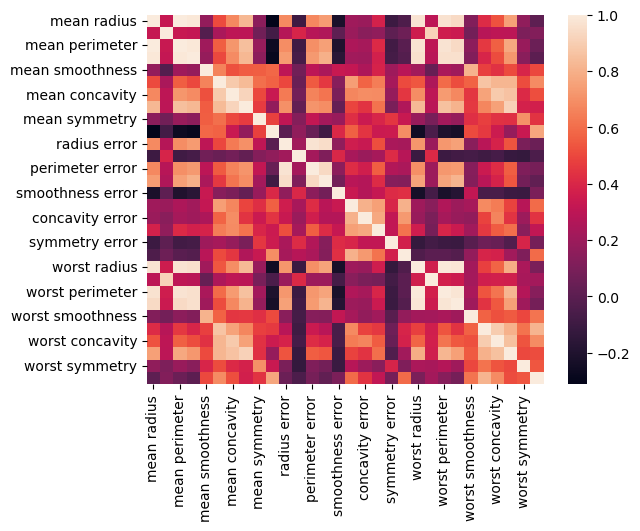

In [74]:
sns.heatmap(X.corr());

It is clear that some features are highly correlated. For example, looking at the correlation heat map (above) we can see that there are many off diagonal light squares indicating a correlation close to 1. To precisely understand which features are most correlated we can list each of the features and their respective absolute correlations along with regression plots of the highest correlated features.

In [75]:
df_corr = X.corr().abs()
corrs = df_corr.stack().sort_values(ascending=False).drop_duplicates()[1:,]
corrs = corrs.rename_axis(('Feature 1', 'Feature 2')).reset_index(
    name='Abs. Correlation')
corrs.head(20)

,Feature 1,Feature 2,Abs. Correlation
0,mean radius,mean perimeter,0.997855
1,worst perimeter,worst radius,0.993708
2,mean radius,mean area,0.987357
3,mean perimeter,mean area,0.986507
4,worst radius,worst area,0.984015
5,worst area,worst perimeter,0.977578
6,radius error,perimeter error,0.972794
7,mean perimeter,worst perimeter,0.970387
8,mean radius,worst radius,0.969539
9,mean perimeter,worst radius,0.969476


Recalling now the data under investigation. The ["Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image." ](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)). Such FNA samples typically appear as in the image below.

![breast cancer image](https://www.frontiersin.org/files/Articles/572671/fdgth-02-572671-HTML/image_m/fdgth-02-572671-g001.jpg)

It is clear that the shape of the cell nuclei is of significant importance in diagnosis, and that the geometric characteristics of these cell nuclie such as area and radius are related. It is also clear then that certain functional dependencies will be present between these features. These dependencies are illustrated by the almost perfect linear correlations between geometric characteristics exhibited in the average radius and perimeter plot (below) and worst radius, worst perimeter plot (below).

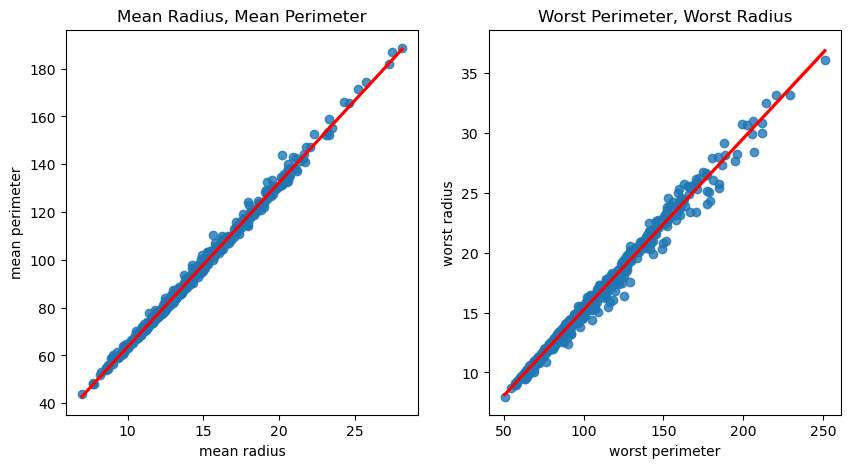

In [76]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.regplot(
    X, x=corrs['Feature 1'][0], 
    y=corrs['Feature 2'][0], 
    line_kws={"color": "red"}
).set(title='Mean Radius, Mean Perimeter');
plt.subplot(1,2,2)
sns.regplot(
    X, x=corrs['Feature 1'][1], 
    y=corrs['Feature 2'][1], 
    line_kws={"color": "red"}
).set(title='Worst Perimeter, Worst Radius');

From the above table and plots we can see that multicollinearity is present in the data. It is therefore suitable to remove some features that exhibit the strongest linear relationship (i.e., it will be sufficient to keep only one of these features). To determine which features to remove we will filter out one of the features where the absolute correlation is greater than 0.95.

In [77]:
tri_corr_mtx = df_corr.mask(np.triu(np.ones_like(df_corr, dtype=bool)))
high_corrs = [c for c in tri_corr_mtx.columns if any(tri_corr_mtx[c] > 0.95)]
high_corrs

['mean radius',
 'mean perimeter',
 'mean area',
 'radius error',
 'worst radius',
 'worst perimeter']

In [78]:
X_reduced = X.drop(high_corrs, axis=1)

Now that we have the appropriate feature set we can see by choosing a number of features at random that the majorities of the points from the two classes (`benign`, `malignant`) are well separated (see scatterplots below). It is reasonable therefore that we can assess that the data are appropriate for binary classification.

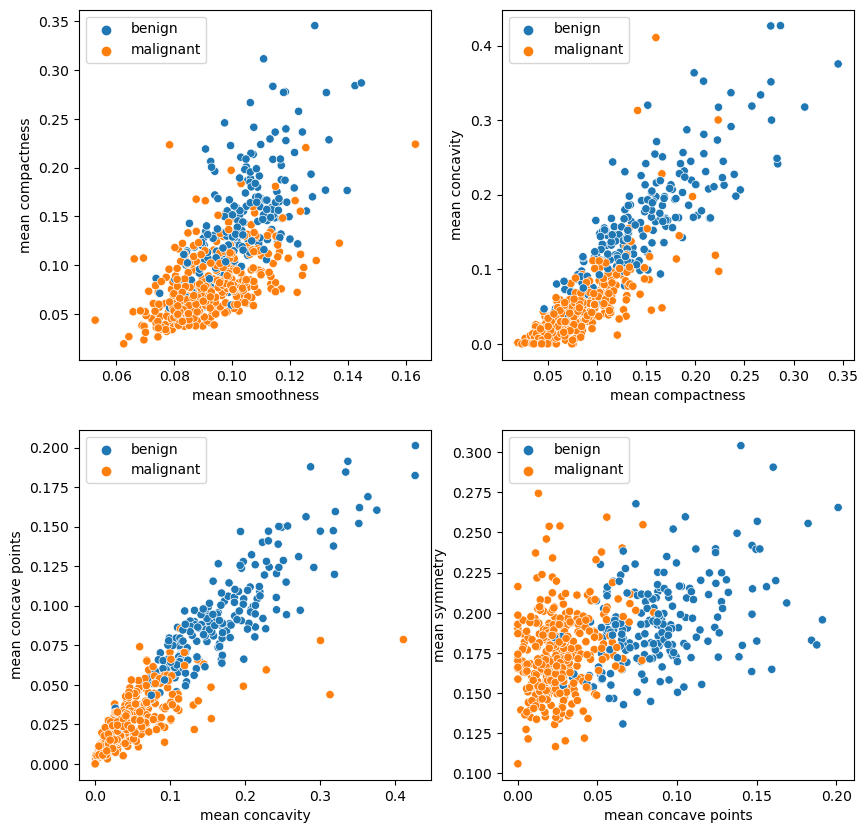

In [79]:
cancer = ['malignant' if y else 'benign' for y in y]

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.scatterplot(X_reduced, x=X_reduced.columns[1], y=X_reduced.columns[2], hue=cancer);
plt.subplot(2,2,2)
sns.scatterplot(X_reduced, x=X_reduced.columns[2], y=X_reduced.columns[3], hue=cancer);
plt.subplot(2,2,3)
sns.scatterplot(X_reduced, x=X_reduced.columns[3], y=X_reduced.columns[4], hue=cancer);
plt.subplot(2,2,4)
sns.scatterplot(X_reduced, x=X_reduced.columns[4], y=X_reduced.columns[5], hue=cancer);

To finalise the data preparation we must partition the data into training and test sets. Because there is a class imbalance (see piechart below) we will stratify the target in order to maintain balanced distribution and set the split proportion to 0.85 (training) and 0.15 (test).

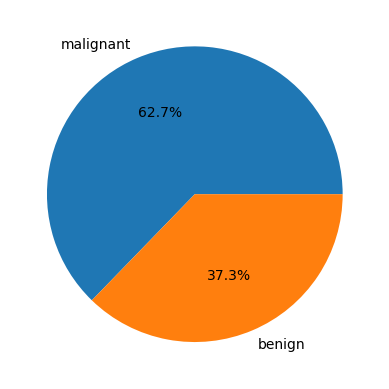

In [80]:
counts = pd.DataFrame(cancer).value_counts()
counts = counts / counts.sum()
plt.pie(counts, labels=['malignant', 'benign'], autopct='%1.1f%%');

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.15, stratify=y, random_state=123
)

## 3.

We may now investigate various decision tree classifiers with different hyperparameter values and compare the perfomance of these models. First we will train a decision tree classifier using the default values for all the hyperparameters and use the trained classifier to perform predictions on the training set and the test set and compare the accuracy scores for the two sets.

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score 

clf_1 = DecisionTreeClassifier(random_state=123)
clf_1.fit(X_train, y_train)

print('Classifier 1 Accuracy (Train):', accuracy_score(y_train, clf_1.predict(X_train))) 
print('Classifier 1 Accuracy (Test): ', accuracy_score(y_test, clf_1.predict(X_test)))

Classifier 1 Accuracy (Train): 1.0
Classifier 1 Accuracy (Test):  0.9418604651162791


Given the classifier has perfect accuracy on the training data it is most reasonable to assume that the model is overfitting. Such high accuracy is seldom encountered in models that exhibit acceptable generalizability (i.e., free of overfitting). To investigate this further we can display the decision tree built from the training process with a visualization.

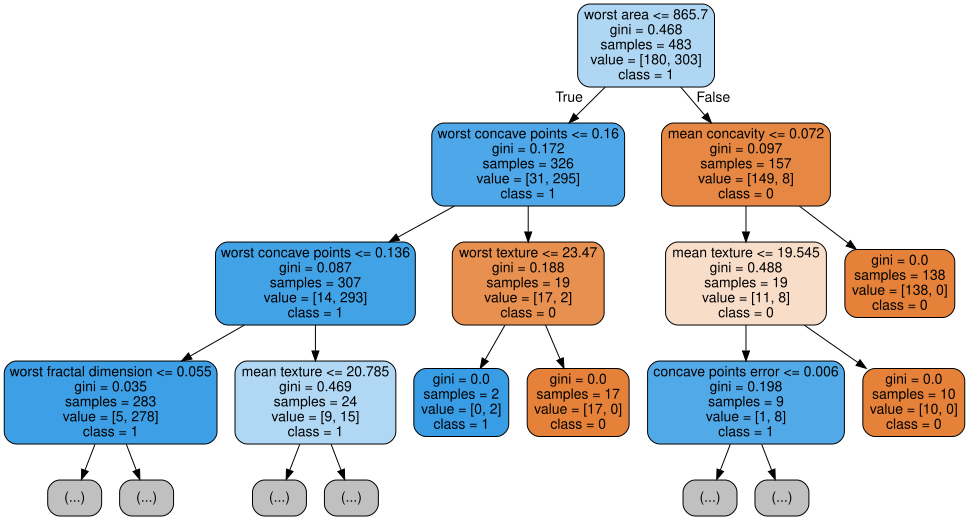

In [83]:
from graphviz import Source
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    clf_1,
    out_file=None,
    max_depth=3,
    feature_names=X_train.columns, 
    class_names=['0','1'],           
    rounded=True,
    filled=True
) 
Source(dot_data) 

Clearly area and concavity are important as variations of these measures in the feature values are determining multiple splits in the top 3 layers of the decision tree (i.e., using `worst area` under 865.7 the tree then splits on `worst concave points` and `mean concavity` before again using the same concavity measure to further refine the tree). Additionally, the decision tree appears to be overfitting the training data (i.e., the purity of the nodes are very high - low Gini). From this we can infer that the default hyperparameter decision tree is fitting the training data with very high granularity and it therefore is appropriate to reduce the flexibilty of the model through hyperparameter tuning. Now we shall construct a second decision tree classifier by setting the hyperparameter `max depth = 3` and compare the accuracy scores for the training set and test sets with those from the previous classifier. 

In [84]:
clf_2 = DecisionTreeClassifier(max_depth=3, random_state=123)
clf_2.fit(X_train, y_train)

print('Classifier 2 Accuracy (Train):', accuracy_score(y_train, clf_2.predict(X_train)))
print('Classifier 2 Accuracy (Test): ', accuracy_score(y_test, clf_2.predict(X_test)))

Classifier 2 Accuracy (Train): 0.968944099378882
Classifier 2 Accuracy (Test):  0.9534883720930233


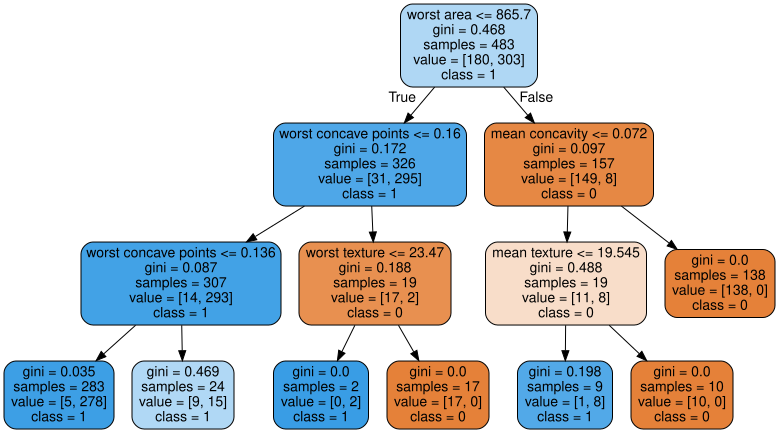

In [85]:
dot_data = export_graphviz(
    clf_2,
    out_file=None,
    feature_names=X_train.columns,
    class_names=['0','1'],           
    rounded=True,
    filled=True
) 
Source(dot_data) 

From the training and test accuracy scores (above) of approx. 0.97 and 0.95 respectively, we see that the hyperparameter setting (`max depth = 3`) has lessened the degree of overfitting in the model. Furthermore, the decision tree is likely to generalize well due to it's simplicity (see above visualization) where again the measures of area and concavity along with texture feature prominently. We can continue the investigation by selecting another different hyperparameter where we shall construct a third decision tree classifier by setting the hyperparameter `min samples split = 5`. 

In [86]:
clf_3 = DecisionTreeClassifier(min_samples_split=5, random_state=123)
clf_3.fit(X_train, y_train)

print('Classifier 3 Accuracy (Train):', accuracy_score(y_train, clf_3.predict(X_train)))
print('Classifier 3 Accuracy (Test): ', accuracy_score(y_test, clf_3.predict(X_test)))

Classifier 3 Accuracy (Train): 1.0
Classifier 3 Accuracy (Test):  0.9418604651162791


Interestingly, it appears that the model is overfitting the training data as was the case with the default hyperparameter values (i.e., perfect training accuracy). This is potentially due to the number of samples required for a decision to be made within the tree being relatively small (i.e., there are 483 samples in the test data and each leaf of the tree need only contain 5 samples representing approx. 10%). Now we shall construct a fourth decision tree classifier by setting the hyperparameter `min samples leaf = 5`. 

In [87]:
clf_4 = DecisionTreeClassifier(min_samples_leaf=5, random_state=123)
clf_4.fit(X_train, y_train)

print('Classifier 4 Accuracy (Train):', accuracy_score(y_train, clf_4.predict(X_train)))
print('Classifier 4 Accuracy (Test): ', accuracy_score(y_test, clf_4.predict(X_test)))

Classifier 4 Accuracy (Train): 0.979296066252588
Classifier 4 Accuracy (Test):  0.9767441860465116


Of the various models we have tried thus far, it appears that the hyperparameter `min samples leaf = 5` is producing superior results (i.e., both training and test accuracy of approx. 0.98 - high accuracy with excellent generalizability on the test data). Finally, we shall perform a 3-fold cross-validation and grid-search to determine the best combination of these hyperparameters (`max depth`, `min samples split` and `min samples leaf`).

In [88]:
from sklearn.model_selection import GridSearchCV

clf_ = DecisionTreeClassifier(random_state=123)
params = {
    "max_depth":[1,2,3,4,5,6,7,8,9,10],  
    "min_samples_split": [2,3,4,5,6,7,8,9,10],
    "min_samples_leaf": [1,2,3,4,5,6,7,8,9,10]
}
clf_cv = GridSearchCV(clf_, params, cv=3)
clf_cv.fit(X_train, y_train) 

clf_cv.best_params_

{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [89]:
print('Classifier CV Accuracy (Train):', accuracy_score(y_train, clf_cv.predict(X_train)))
print('Classifier CV Accuracy (Test): ', accuracy_score(y_test, clf_cv.predict(X_test)))

Classifier CV Accuracy (Train): 0.968944099378882
Classifier CV Accuracy (Test):  0.9534883720930233


The cross validation grid search has identified the best hyperparameter values as:
- `max depth = 3`
- `min samples leaf = 2`
- `min samples split = 2`

This combination results in training accuracy scores averaged across the 3 cross validation partitions of approx. 0.97 and a test set accuracy of 0.95. The small decline in accuracy across both training and test data in comparison to the previous model with the single hyperparameter `min samples leaf = 5` is acceptable given the greater rigour with which the model is evaluated using the cross validation framework - what is important is the relative difference between training and test error given that the accuracy measures are very high under both classifiers. 

In order to better determine the performance differences between the various classifiers (on the test data) we shall collect the `accuracy`; `precision`; `recall`; `f1`; and area under the ROC curve `roc auc` into a data frame and display the results.

In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

classifiers = [clf_1, clf_2, clf_3, clf_4, clf_cv]
params = ['default', 'max_depth=3', 'min_samples_split=5', 'min_samples_leaf=5', 'cv_grid_search']

results = {
    'accuracy': [accuracy_score(y_test, classifier.predict(X_test)) for classifier in classifiers],
    'precision': [precision_score(y_test, classifier.predict(X_test)) for classifier in classifiers],
    'recall': [recall_score(y_test, classifier.predict(X_test)) for classifier in classifiers],
    'f1': [f1_score(y_test, classifier.predict(X_test)) for classifier in classifiers],
    'roc auc': [roc_auc_score(y_test, classifier.predict(X_test)) for classifier in classifiers]
}

results_df = pd.DataFrame(results, index=params)
results_df

,accuracy,precision,recall,f1,roc auc
default,0.941860,0.962264,0.944444,0.953271,0.940972
max_depth=3,0.953488,0.946429,0.981481,0.963636,0.943866
min_samples_split=5,0.941860,0.962264,0.944444,0.953271,0.940972
min_samples_leaf=5,0.976744,0.981481,0.981481,0.981481,0.975116
cv_grid_search,0.953488,0.946429,0.981481,0.963636,0.943866


By inspecting the results we can see that the classifiers have similar performance. On balance it is the classifier with hyperparameter `min samples leaf = 5` and the cross validated grid search classifier that are likely the optimal models under this framework. Interestingly, from these metrics, it appears that the `min samples leaf = 5` classifier is superior to the optimal grid search classifier (i.e., equal or greater performance across all metrics). To understand this better we can examine the confusion matrices of these classifiers.

In [91]:
from sklearn.metrics import confusion_matrix

def display_conf_mtx(conf_mtx, title):
    cells = [
        f"{label_1}\n{label_2}\n{label_3}" for label_1, label_2, label_3 in zip(
            ['True Neg','False Pos','False Neg','True Pos'],
            ["{0:0.0f}".format(value) for value in conf_mtx.flatten()],
            ["{0:.2%}".format(value) for value in conf_mtx.flatten()/np.sum(conf_mtx)]
        )
    ]
    cells = np.asarray(cells).reshape(2,2)
    sns.heatmap(conf_mtx, annot=cells, fmt='', cmap='viridis').set(title=title)


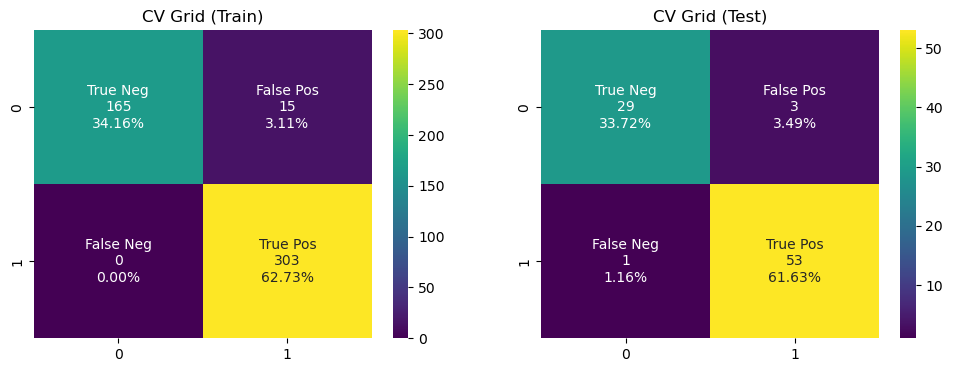

In [92]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
conf_mtx_1 = confusion_matrix(y_train, clf_cv.predict(X_train), labels=clf_cv.classes_)
display_conf_mtx(conf_mtx_1, title='CV Grid (Train)')
plt.subplot(1,2,2)
conf_mtx_2 = confusion_matrix(y_test, clf_cv.predict(X_test), labels=clf_cv.classes_)
display_conf_mtx(conf_mtx_2, title='CV Grid (Test)')

Examining the confusion matrices (above) we see that the error proportions (`False Positive`, `False Negative`) are stable across training and test data but we note a slight increase in the `False Negative` classifications on the test data (i.e., from 0 errors (0.00%) to 1 error (1.16%)). Furthermore, the accuracy of classifications (`True Negative`, `True Positive`) are also maintained across the training and test data (i.e., approx. 34% and 62% respectively). Let us now examine the confusion matrices of the `min samples leaf = 5` classifier on the training and test data.

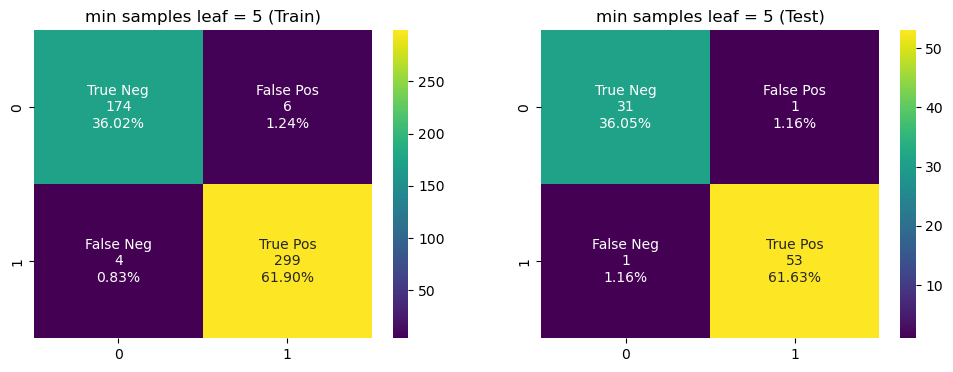

In [93]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
conf_mtx_1 = confusion_matrix(y_train, clf_4.predict(X_train), labels=clf_cv.classes_)
display_conf_mtx(conf_mtx_1, title='min samples leaf = 5 (Train)')
plt.subplot(1,2,2)
conf_mtx_2 = confusion_matrix(y_test, clf_4.predict(X_test), labels=clf_cv.classes_)
display_conf_mtx(conf_mtx_2, title='min samples leaf = 5 (Test)')

The `min samples leaf = 5` classifier number makes approx. 50% less `False Positive` errors on the training than that of the grid search classifier (i.e., 15 (3.11%) compared to 6 (1.24%)) but the number of `False Negative` errors has increased from 0 (0.00%) to 4 (0.83%) respectively. Regarding the test data, which is of obviously greater importance, the number of `False Negative` errors is equal for the two classifiers (i.e., 1 error (1.16%) in both cases) but the grid search classifier makes two greater `False Positive` errors than the `min samples leaf = 5` classifier (i.e., 3 (3.49%) as opposed to 1 (1.16%)). An important consideration is necessary regarding these data - the objective of the classifier is to use the data to determine the malignancy of a breast cancer sample. In such cases as this, there is much greater importance on preventing `False Negative` diagnosis than in correctly identifying a `True Positive` diagnosis and also in making a `False Positive` error. For this reason, the __False Negative Rate__ is critically important in the determination of the optimal classifier. Ideally, the __False Negative Rate__ should be as small as possible. From the results (below) we can see that both the `min samples leaf = 5` and grid search classifiers produce the same __False Negative Rate__ on the test data. But, importantly, the rate of approx. 0.02 indicates that out of a sample of 100 breast cancer samples, these classifiers would fail to determine a malignant cancer in 2 of the cases. Taking these observations into consideration, the most appropriate course of action is to acquire more data (perhaps with greater variability in the feature distributions) and to further investigate classifier models.

In [94]:
TN, FP, FN, TP = confusion_matrix(y_test, clf_4.predict(X_test)).ravel()
FNR_1 = FN/(TP+FN)
TN, FP, FN, TP = confusion_matrix(y_test, clf_cv.predict(X_test)).ravel()
FNR_2 = FN/(TP+FN)
print('False Negative Rate (min samples leaf = 5): ', FNR_1)
print('False Negative Rate (CV grid search): ', FNR_2)

False Negative Rate (min samples leaf = 5):  0.018518518518518517
False Negative Rate (CV grid search):  0.018518518518518517


## Regression Modelling of the Concrete Slump Test Data 

### Exploratory Data Analysis and Preprocessing

We will now use the [Concrete Slump Test data](https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test) to perform regression where, for any new test instance, our aim is to use our trained regression model to predict the `28-day Compressive Strength (Mpa)` value of the concrete. To begin we shall load the data and begin a preliminary investigation of it's characteristics.

In [95]:
slump = pd.read_csv('slump_test.data')
slump.head()

,No,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,1,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,2,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,3,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,4,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,5,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


In [96]:
slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   No                                  103 non-null    int64  
 1   Cement                              103 non-null    float64
 2   Slag                                103 non-null    float64
 3   Fly ash                             103 non-null    float64
 4   Water                               103 non-null    float64
 5   SP                                  103 non-null    float64
 6   Coarse Aggr.                        103 non-null    float64
 7   Fine Aggr.                          103 non-null    float64
 8   SLUMP(cm)                           103 non-null    float64
 9   FLOW(cm)                            103 non-null    float64
 10  Compressive Strength (28-day)(Mpa)  103 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 9.0 KB

There are 7 numeric input variables (i.e., feature columns) measured in $ kg / m^{3} $:
- `Cement`
- `Slag`
- `Fly ash`
- `Water`
- `SP`
- `Coarse Aggr.`
- `Fine Aggr.`

Additionally there are 3 potential output variables (i.e., predictors). Our interest is the `28-day
Compressive Strength` output, so the other two output variables (`SLUMP(cm)` and `FLOW(cm)`) can be removed.


In [97]:
slump = slump.drop(['SLUMP(cm)', 'FLOW(cm)', 'No'], axis=1)
target = slump.columns[-1]

slump.isnull().sum()

Cement                                0
Slag                                  0
Fly ash                               0
Water                                 0
SP                                    0
Coarse Aggr.                          0
Fine Aggr.                            0
Compressive Strength (28-day)(Mpa)    0
dtype: int64

We see that the data is free of missing values and can therefore initiate some basic exploration. To begin we can inspect the scatter plots and histograms of the features. 

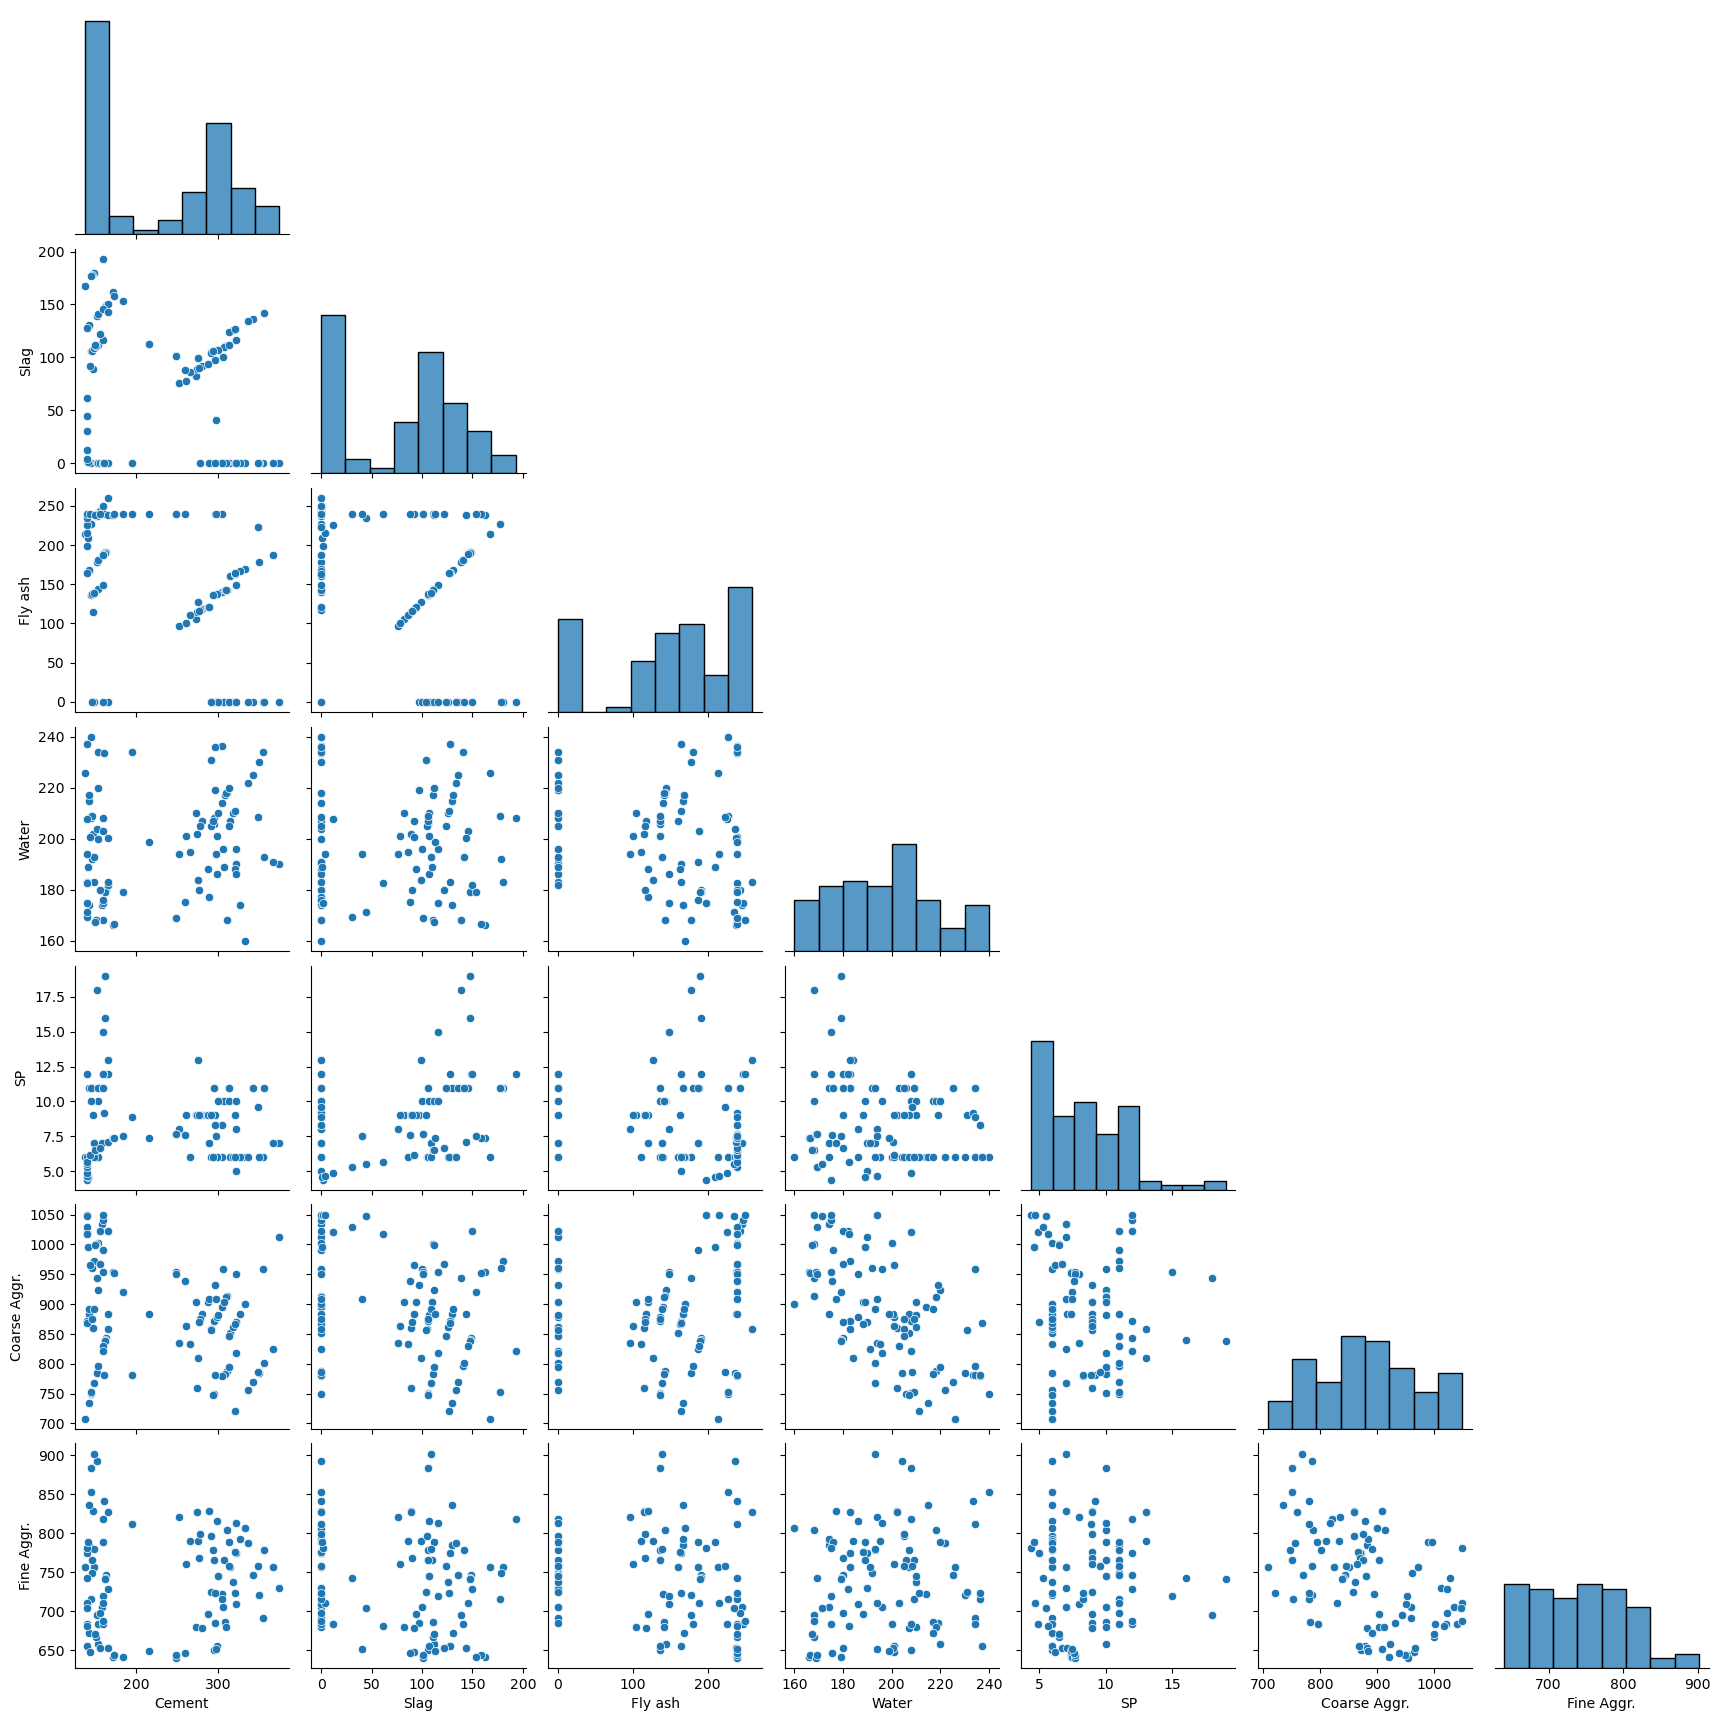

In [98]:
sns.pairplot(slump.loc[:, slump.columns != target], corner=True)
plt.show()

We see that the feature distributions range in shape and that skew and bimodality is present in some features. It will therefore be appropriate to scale the data before computing regression models. Additionally, the scatterplots do not appear to indicate the presence of strong linear correlation in any of the features. To preciseley determine if linear relationships are present we will compute tha absolute correlation between each of the features.

In [99]:
df_corr = slump.loc[:, slump.columns != target].corr().abs()
corrs = df_corr.stack().sort_values(ascending=False).drop_duplicates()[1:,]
corrs = corrs.rename_axis(('Feature 1', 'Feature 2')).reset_index(
    name='Abs. Correlation')
corrs

,Feature 1,Feature 2,Abs. Correlation
0,Water,Coarse Aggr.,0.602201
1,Fine Aggr.,Coarse Aggr.,0.488537
2,Cement,Fly ash,0.486535
3,Slag,Fly ash,0.322619
4,Cement,Coarse Aggr.,0.309857
5,Slag,SP,0.306504
6,Fly ash,Fine Aggr.,0.282854
7,Cement,Slag,0.243553
8,Fly ash,Water,0.241321
9,Coarse Aggr.,Slag,0.223792


As we can see from the correlation table above, the highest absolute correlation is approx. 0.60 between `Water` and `Course Aggr.` This indicates that the features are sufficiently uncorrelated that we need not remove any in order to ameliorate the potential presence of multicollinearity. Now we are aware that the presence of outliers has the potential to negatively affect the accuracy of regression models applied on the data. Hence we must determine if outliers are present in the data and necessarily remove them if so. Boxplots are appropriate for this task.

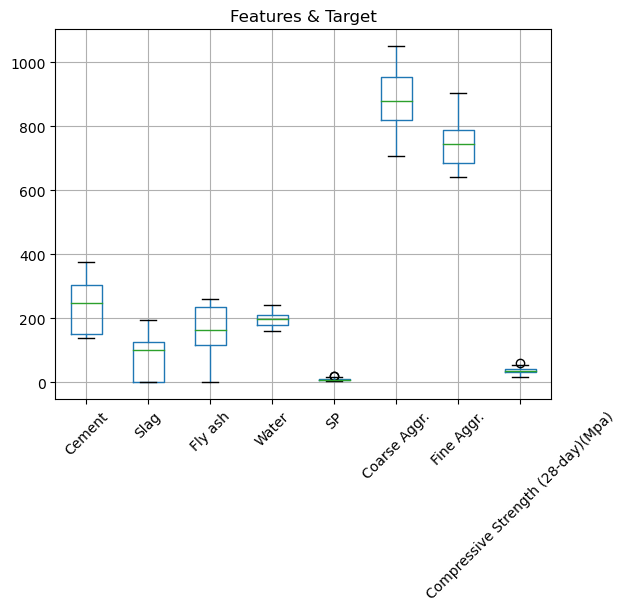

In [100]:
slump.boxplot()
plt.xticks(rotation=45)
plt.title('Features & Target');

We see that both `SP` and the target `Compressive Strength (28-day)(Mpa)` contain outliers.

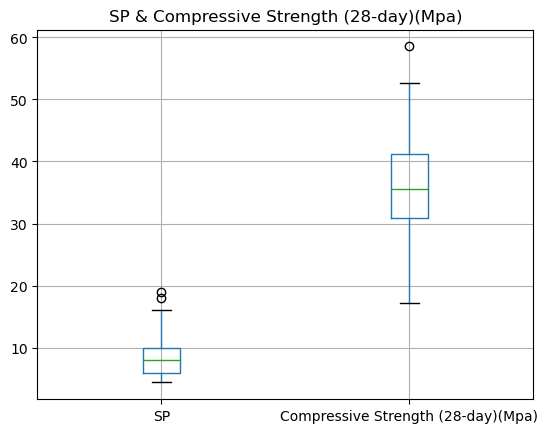

In [101]:
slump[['SP', target]].boxplot()
plt.title('SP & Compressive Strength (28-day)(Mpa)');

As previously noted, we know that in the case of regression modelling, outliers have a tendency to negatively affect predictive accuracy due to the outsized effect they have on the distributional characteristics of the predictor (feature) variables. For this reason it is appropriate that we remove the outliers from the data before proceeding with fitting our regression models. We can implement a function to preform this task and incorporate it into the final data preparation framework.

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def remove_outliers(data):
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1 
        filter = (
            data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 *IQR
            )
        data = data.loc[filter]  
    return data


def prepare_data(data, target, test_prop):
    data = remove_outliers(data)
    X = data.drop(target, axis=1)
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_prop, random_state=123
    )
    std_scaler = StandardScaler().fit(X_train)
    X_train_std = std_scaler.transform(X_train)
    X_test_std = std_scaler.transform(X_test)
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    return X_train_std, X_test_std, y_train, y_test

We are now able to finalise the data preprocessing and preparation by performin the necessary transformations and cleaning along with splitting the data into training and test sets. In our case we will use a test set proportion of 20%.

In [103]:
X_train, X_test, y_train, y_test = prepare_data(slump, target, 0.20)

### Regression Modelling

With the data prepared, we can begin an investigation of various regression models. To acheive this we will utilize a Voting regressor framework. As describe in the __scikit-learn__ documentation: [A voting regressor is an ensemble meta-estimator that fits several base regressors, each on the whole dataset. Then it averages the individual predictions to form a final prediction](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingRegressor.html)

For the Voting regressor, we will use the following as the 3 base estimators with default hyperparameters:
- a linear `SVM` regressor 
- a linear regressor (using the `LinearRegression` class)
- a `Stochastic Gradient Descent` regressor

We will train the base estimators and the Voting regressor on the training set and compare their predicted `28-day Compressive Strength` values for the test set, report their Root Mean Square Error (RMSE) and illustrate the predicted values versus the ground truth values of all the test instances.

In [104]:
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

svr = SVR(kernel='linear')
sgd = SGDRegressor(random_state=123)
lin = LinearRegression()
voting_reg = VotingRegressor(
    estimators=[('svr', svr), ('sgd', sgd), ('lin', lin)]
)

reg_models = [svr, sgd, lin, voting_reg]
model_preds = []

for model in reg_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    model_preds.append((y_pred, model.__class__.__name__))
    print(model.__class__.__name__, 'RMSE: ', round(rmse, 3)) 



SVR RMSE:  2.37
SGDRegressor RMSE:  2.635
LinearRegression RMSE:  2.692
VotingRegressor RMSE:  2.544


From the reported RMSE of each regression model (above) we see that the linear Support Vector Machine (i.e., `SVR`)
model produces the lowest error. Additionally, we note that the regression models all have similar performance, i.e., the absolute difference between best (`SVR`) and worst (`LinearRegression`) is approx. 0.32. Now, for each respective classifier, we can plot the predicted values versus the ground truth values of all the test instances.

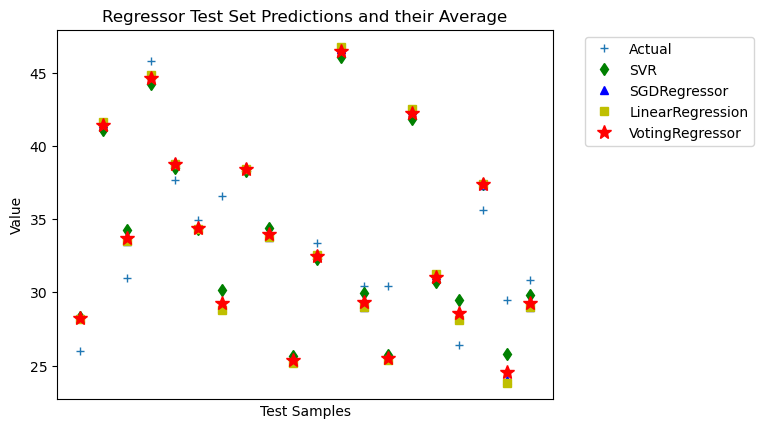

In [105]:
plt.figure()
plt.plot(y_test, "+", label="Actual")
plt.plot(model_preds[0][0], "gd", label=model_preds[0][1])
plt.plot(model_preds[1][0], "b^", label=model_preds[1][1])
plt.plot(model_preds[2][0], "ys", label=model_preds[2][1])
plt.plot(model_preds[3][0], "r*", ms=10, label=model_preds[3][1])
plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("Value")
plt.xlabel("Test Samples")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
plt.title("Regressor Test Set Predictions and their Average")
plt.show()

From the plot above, it is clear (as was the case for RMSE) that all of the regression model predictions of the test instances are similar (i.e., points produced by `SVR`, `SGDRegressor` and `LinearRegression` are close together). Interestingly, there is a dispersion between the `Actual` test instances (blue crosses) and the `VotingRegressor` (red stars) in approx. 13 of 20 (65%) of the test samples and that there is a quite significant difference in at least 2 of these (10%) (i.e., indicated by the relative distance of the blue cross from the red star). Continuing with our regression modelling, we can tune a number of hyperparameters for each of these base estimators useing 3-fold cross-validation with Grid-Search to select the best hyperparameters.

In [106]:
from sklearn.model_selection import GridSearchCV

svr_params = {
    'kernel': ['linear','poly'],
    'degree': [1,2,3],
    'C': [1,10,100],
    'gamma': 10.0 ** -np.arange(1, 5),
    'epsilon': [0.1,0.5,1.0,1.5]
}

sgd_params = {
    'penalty': ['l1', 'l2'],
    'alpha': 10.0 ** -np.arange(1, 5),
    'learning_rate': ['constant', 'optimal', 'invscaling']
}

sgd_grid = GridSearchCV(sgd, sgd_params, scoring='neg_mean_squared_error', cv=3)
sgd_grid.fit(X_train, y_train)
sgd_grid_rmse = round(mean_squared_error(y_train, sgd_grid.predict(X_train), squared=False), 3)

svr_grid = GridSearchCV(svr, svr_params, scoring='neg_mean_squared_error', cv=3)
svr_grid.fit(X_train, y_train)
svr_grid_rmse = round(mean_squared_error(y_train, svr_grid.predict(X_train), squared=False), 3)

print(svr_grid.__class__.__name__, 'SVR:', svr_grid.best_params_, 'RMSE:', svr_grid_rmse)
print(sgd_grid.__class__.__name__, 'SGD:', sgd_grid.best_params_, 'RMSE:', sgd_grid_rmse)

GridSearchCV SVR: {'C': 100, 'degree': 1, 'epsilon': 1.5, 'gamma': 0.1, 'kernel': 'poly'} RMSE: 2.419
GridSearchCV SGD: {'alpha': 0.0001, 'learning_rate': 'constant', 'penalty': 'l2'} RMSE: 2.35


The hyperparameter grid (above) utilizes a combination of parameters to tune the Support Vector Machine Regression (`SVR`) model, and the Stochastic Gradient Descent Regression (`SGDRegressor`) model with cross validation. 

For the `SVR` model we have chosen to tune the following parameters:
- `kernel` specifies the type of kernel to use, i.e., `linear` or `poly` (polynomial).
- `degree` specifies the order of the polynomial kernel function.
- `C` specifies the degree of model regularization, i.e., it represents the trade off between misclassification of training examples against the simplicity of the decision surface. Decreasing `C` corresponds to more regularization.
- `gamma` specifies how far the influence of a single training example reaches, with low values meaning ‘far’ and high values meaning ‘close’. The gamma parameters can be seen as the inverse of the radius of influence of samples selected by the model as support vectors.
- `epsilon` specifies the epsilon-tube within which no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value.

For the `SGDRegressor` model we have chosen to tune the following parameters:
- `penalty` specifies the regularization term to be used (i.e., a penalty applied to the loss function).
- `alpha` specifies a constant that multiplies the regularization term. The higher the value, the stronger the regularization.
- `learning rate` specifies the learning rate schedule (i.e., rate of potential convergence).

As we see (above) the cross-validation grid search has resulted in optimal parameter values and training __RMSE__:
- `SVR` `C`: 100, `degree`: 1, `epsilon`: 1.5, `gamma`: 0.1, `kernel`: `poly`, __RMSE__: 2.41
- `SGDRegressor` `alpha`: 0.0001, `learning_rate`: constant, `penalty`: l2 __RMSE__: 2.35

Now we can assemble each of these optimised models within a Voting regressor, compute the test set errors and compare the results.

In [107]:
voting_reg_grid = VotingRegressor(
    estimators=[('svr_grid', svr_grid), ('sgd_grid', sgd_grid), ('lin', lin)]
)

reg_grid_models = [svr_grid, sgd_grid, lin, voting_reg_grid]
grid_model_preds = []
model_names = ['SVRGrid', 'SGDGrid', 'LinearRegression', 'VotingRegressor']

for model, model_name in zip(reg_grid_models, model_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, squared=False)
    grid_model_preds.append((y_pred, model_name))
    print(model_name, 'RMSE: ', round(mse, 3))

SVRGrid RMSE:  2.884
SGDGrid RMSE:  2.7
LinearRegression RMSE:  2.692
VotingRegressor RMSE:  2.751


Inspecting the results above we note that the additional model complexity does not appear to translate to increased performance on the test data over and above the default parameterizations for our regression models (i.e., __RMSE__ measures have increased for the both the `SVRGrid` and `SGDGrid` models and respective `VotingRegressor`). Interestingly though, the __RMSE__ has stayed constant between the training and test sets for the `SVRGrid` (2.884) whilst the __RMSE__ has increased from 2.35 on the training data to 2.7 on the test data for the `SGDGrid`. Now, for each respective classifier, we can plot the predicted values versus the ground truth values of all the test instances.

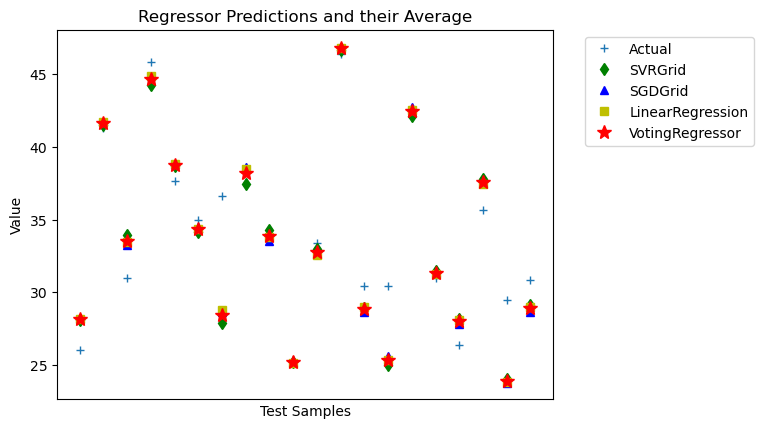

In [108]:
plt.figure()
plt.plot(y_test, "+", label="Actual")
plt.plot(grid_model_preds[0][0], "gd", label=grid_model_preds[0][1])
plt.plot(grid_model_preds[1][0], "b^", label=grid_model_preds[1][1])
plt.plot(grid_model_preds[2][0], "ys", label=grid_model_preds[2][1])
plt.plot(grid_model_preds[3][0], "r*", ms=10, label=grid_model_preds[3][1])
plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("Value")
plt.xlabel("Test Samples")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
plt.title("Regressor Predictions and their Average")
plt.show()

As expected, the results are very similar for those of the default parameterization models. One difference though is the appearance of a slightly improved coherence between the prediction outcomes of the models (i.e., there is less dispersion among the predictions of each respective model). On the other hand, this appears to come at the cost of slightly less predictive accuracy with the respect to the actual test instances (i.e., there appears to be greater dispersion between the model outcomes and the actual test values). With these observations in mind, it is resonable to conclude that in the case of the limited amount of data available (80 training samples, 20 test samples) the additionall model complexity accrued through hyperparameter tuning of the Support Vector Machine and Stochastic Gradient Descent regression models does not lead to improvements prediction capacity of the respective models.

## Decision Tree & Random Forest Regression Modelling of the Abalone Data 

The [abalone dataset](https://archive.ics.uci.edu/ml/datasets/Abalone) contains 4177 instances with 8 attributes and a column that describes the age, represented in terms of the number of rings, of the abalones. From the description of the dataset we see that:

_Predicting the age of abalone from physical measurements. The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- a boring and time-consuming task. Other measurements, which are easier to obtain, are used to predict the age. Further information, such as weather patterns and location (hence food availability) may be required to solve the problem._

For our purposes we seek to predict the age (i.e., rings) of the abalone for any new test instance. That is we want to train Decision Tree and Random Forest regression models to be able to predict this value. We will begin by performing the usual data inspection and cleaning and appropriate data preprocessing.

### Exploratory Data Analysis and Preprocessing

In [109]:
column_names = [
    "sex", "length", "diameter", "height", "whole weight", 
    "shucked weight", "viscera weight", "shell weight", "rings"
]
abalone = pd.read_csv("abalone.data", names=column_names)

abalone.head()

,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


The first observation to make is that there are categorical variables (features) present in the data - `sex` is indicated by:

- `M`: Male
- `F`: Female
- `I`: Infant

Because we aim to perform regression modelling we must either discard the such variables or appropriately encode them. We shall return to this when performing preprocessing and transformation. The remaining variables are numeric and pertain to measures of the abalone shell geometry and it's physical characteristics and, as indicated in the data description, these values are suitable proxy indications for abalone age (i.e., number of rings). 

In [110]:
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole weight    4177 non-null   float64
 5   shucked weight  4177 non-null   float64
 6   viscera weight  4177 non-null   float64
 7   shell weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [111]:
abalone.isnull().sum()

sex               0
length            0
diameter          0
height            0
whole weight      0
shucked weight    0
viscera weight    0
shell weight      0
rings             0
dtype: int64

We see that the data is free of missing values and can therefore initiate some basic exploration. To begin we can inspect the scatter plots and kernel densities of the features.

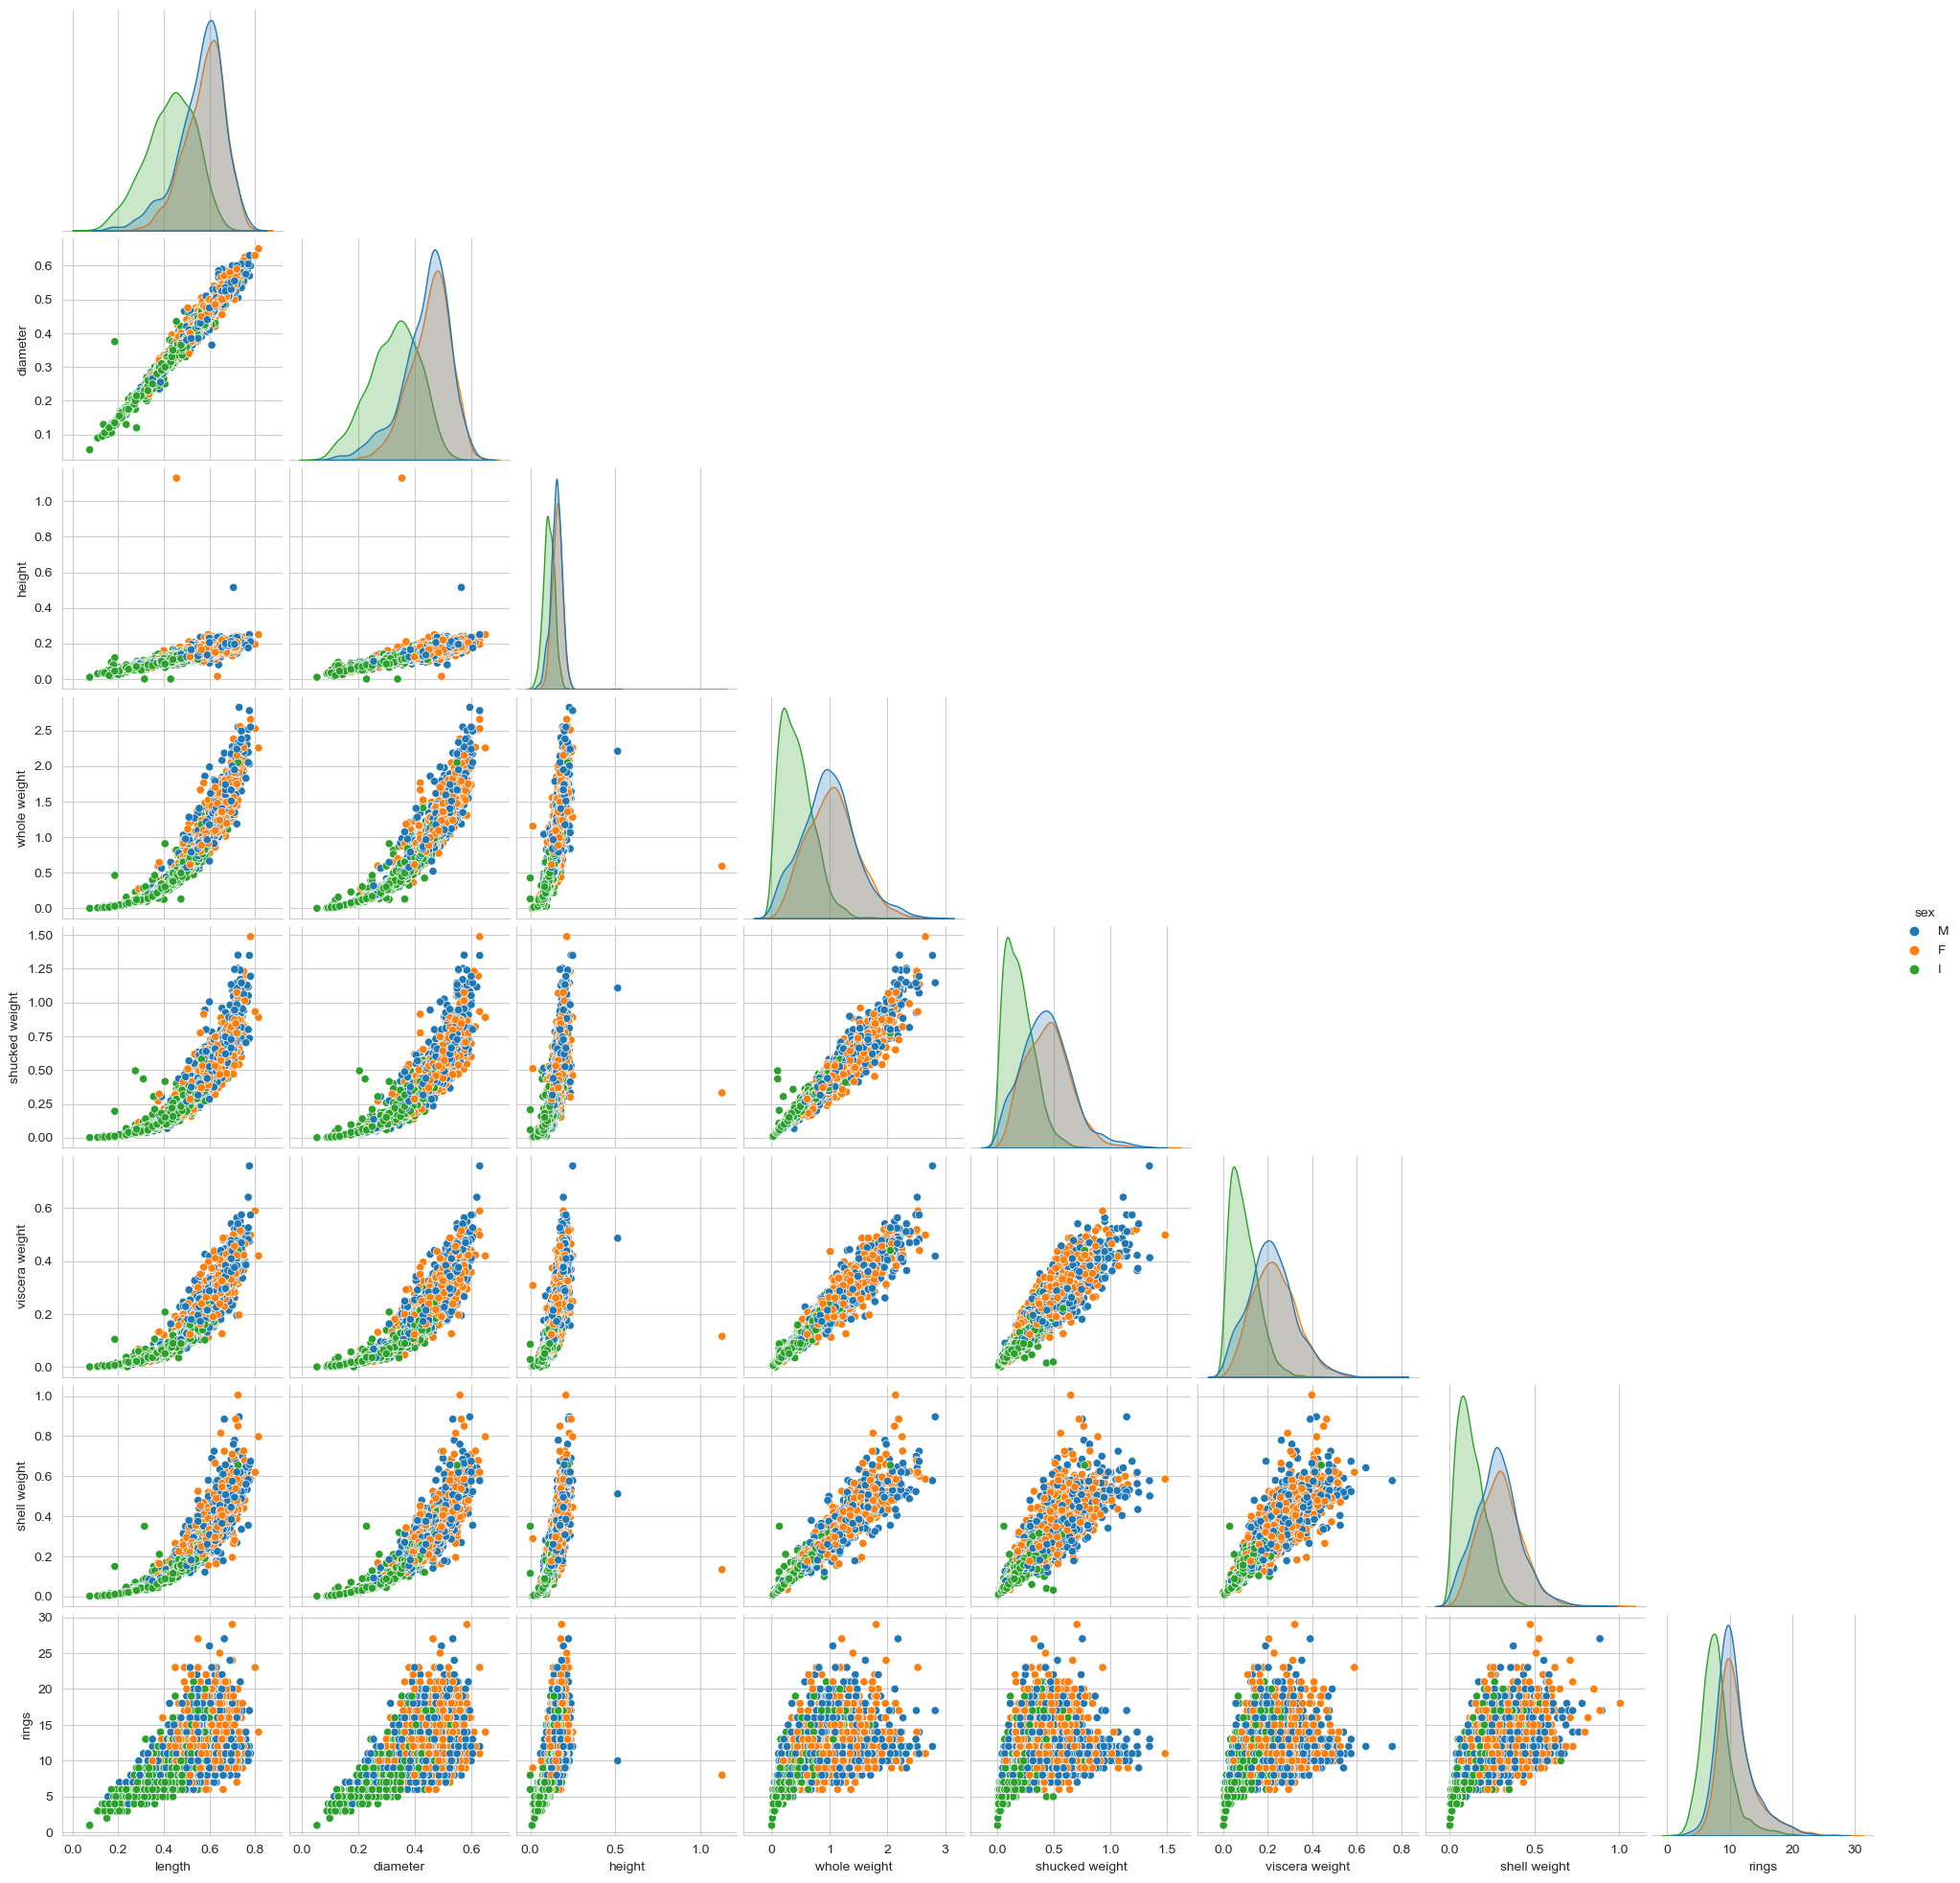

In [112]:
sns.set_style('whitegrid')
sns.pairplot(abalone, hue="sex", corner=True);

As expected we see that the kernel densities differ for between `Infants` (green) and adults (i.e., `Male`, `Female`). This difference is indicated by the rightward shift in distribution of the adults, away from the infants which, of course, indicates older and larger abalone. Due to the the data being composed of geometric and physical characteristics it is clear that correlations among the various measures will be present - this is indicated in some of the scatter plots. Due to the small number of features available and the relatively restrictive measures (all similar in nature apart from `sex`) we will maintain all the respective features in the training and test data. Finally, we can see a number of what appear to be outliers in the scatterplots. As was outlined earlier, we are aware that the presence of outliers has the potential to negatively affect the accuracy of regression models, and we must necessarily remove them if present. We can again use boxplots for this task. 

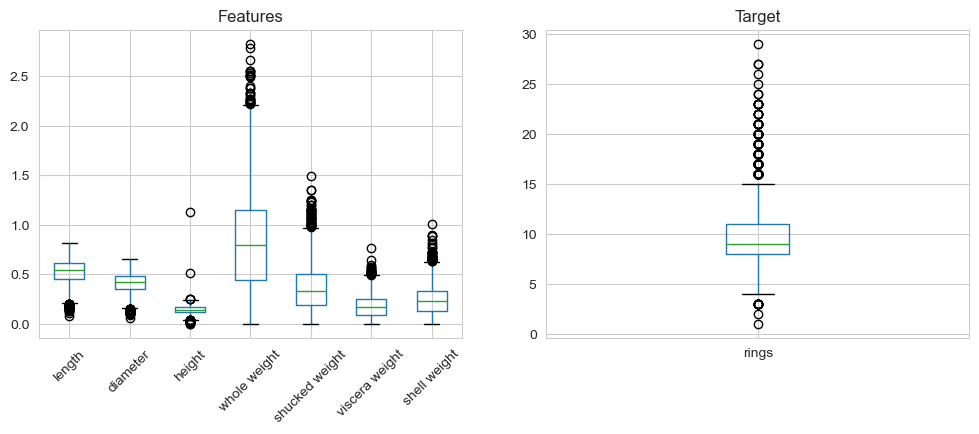

In [113]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
abalone.loc[:, abalone.columns != 'rings'].boxplot()
plt.title('Features')
plt.xticks(rotation=45);
plt.subplot(1,2,2)
abalone[['rings']].boxplot()
plt.title('Target');

Inspecting the above boxplots for the features and target we see a strong presence of outliers in both cases. We will thus need to remove them before training the regression models. As we described previously, this can be performed in conjuction with other preprocessing tasks such as scaling. Before we carry out this final preprocessing stage we must return to the categorical variable `sex` where we will need to encode this variable as numeric. The reason for retaining the `sex` variable as opposed to discarding it is for the obvious implication of sex differences (particularly with respect to infant abalone) being related to geometric and physical characteristics of the abalone shells. Such encoding can be acheived via the One Hot method. Finally, we can recycle the data preprocessing functionality defined earlier to complete the preparation with an 85/15 random split to form a training and test set.

In [114]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
sex_enc = ohe.fit_transform(abalone[['sex']])
abalone[ohe.categories_[0]] = sex_enc.toarray()
abalone = abalone.drop('sex', axis=1)

X_train, X_test, y_train, y_test = prepare_data(abalone, 'rings', 0.15)

### Regression Modelling

Now we are able to begin regression modelling. Firstly, we will train a decision tree regression model using a 3-fold cross-validation to tune the `max depth` hyperparameter, letting all other hyperparameters remain with their default values. We then can display a plot of the training errors, cross-validation errors and test errors as a function `max depth` hyperparameter. 

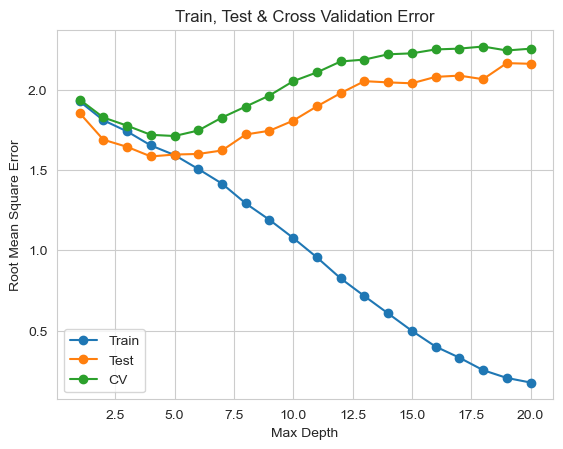

In [115]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

dtr = DecisionTreeRegressor(random_state=123)
tree_depths = np.arange(1,21)
params = {'max_depth': tree_depths}
dtr_grid = GridSearchCV(
    dtr, param_grid=params, 
    scoring='neg_mean_squared_error', 
    cv=3, return_train_score=True)
dtr_grid.fit(X_train, y_train)

rmse_train = []
rmse_test = []
for depth in tree_depths:
    dtr_ = DecisionTreeRegressor(max_depth=depth)
    dtr_.fit(X_train, y_train)
    rmse_train.append(mean_squared_error(y_train, dtr_.predict(X_train), squared=False))
    rmse_test.append(mean_squared_error(y_test, dtr_.predict(X_test), squared=False))

plt.plot(tree_depths, rmse_train, '-o', label='Train')
plt.plot(tree_depths, rmse_test, '-o', label='Test')
plt.plot(tree_depths, np.sqrt(-dtr_grid.cv_results_['mean_test_score']), '-o', label='CV')
plt.xlabel('Max Depth')
plt.ylabel('Root Mean Square Error')
plt.title('Train, Test & Cross Validation Error')
plt.legend()
plt.show()

As expected, the __RMSE__ on the training data declines as the depth of the regression tree increases, thereby increasing the likelihood of overfitting the training data. Turning to the the cross validation and test errors, we see that the curves remain close together albeit with a slightly greater gap as depth increases. That these curves are not diverging rapidly and that tree depth is in the same range where the error is minimized indicates that the generalizability of the model is likely acceptable. Given these results, it is reasonable to conclude that the `max depth` hyperparameter is optimal in the range of $[3,5]$ in this circumstance. Indeed, the grid search identified a `max depth` of 5 to be optimal (see below).

In [116]:
dtr_grid.best_params_

{'max_depth': 5}

Now, using a `max depth` of 5, we shall similarly train a decision tree regression model again using a 3-fold cross-validation to tune the `min samples leaf` hyperparameter, and letting all other hyperparameters remain as their default values. We will then make a plot of the training errors, cross-validation errors and test errors as a function min samples leaf.

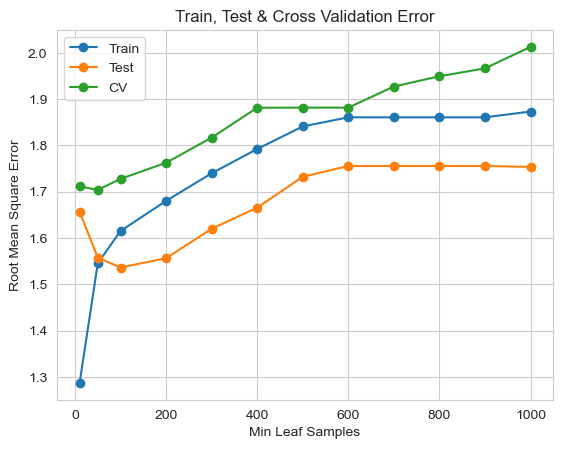

In [117]:
dtr = DecisionTreeRegressor(max_depth=5, random_state=123)
leaf_samples = np.concatenate((np.array([10,50]), np.arange(0, 1100, 100)[1:]))
params = {'min_samples_leaf': leaf_samples}
dtr_grid = GridSearchCV(
    dtr, param_grid=params, 
    scoring='neg_mean_squared_error', 
    cv=3, return_train_score=True)
dtr_grid.fit(X_train, y_train)

rmse_train = []
rmse_test = []
for leaf_sample in leaf_samples:
    dtr_ = DecisionTreeRegressor(min_samples_leaf=leaf_sample)
    dtr_.fit(X_train, y_train)
    rmse_train.append(mean_squared_error(y_train, dtr_.predict(X_train), squared=False))
    rmse_test.append(mean_squared_error(y_test, dtr_.predict(X_test), squared=False))

plt.plot(leaf_samples, rmse_train, '-o', label='Train')
plt.plot(leaf_samples, rmse_test, '-o', label='Test')
plt.plot(leaf_samples, np.sqrt(-dtr_grid.cv_results_['mean_test_score']), '-o', label='CV')
plt.xlabel('Min Leaf Samples')
plt.ylabel('Root Mean Square Error')
plt.title('Train, Test & Cross Validation Error')
plt.legend()
plt.show()

As expected, when the minimum number of samples required in a leaf node of the regression tree is lowest, the __RMSE__ on the training data is also lowest. Additionally, the gap between the cross validation and test error curves are relatively large for all of the `min samples leaf` values except when such values are quite small, i.e., between approx. 10 and 100 samples. It is therefore likely within this range that the optimal value for this hyperparameter lies. As we can see (below) the grid search identified 50 as the minimum number of samples for each leaf as optimal.

In [118]:
dtr_grid.best_params_

{'min_samples_leaf': 50}

To continue our investigation of regression modelling we will implement a number of random forest regressors with 500 estimators. Utilizing our previous results, we will specify the `max depth`, and `min samples leaf` hyperparameters as 5 and 50 respectively. Additionally, we will manually experiment with other hyperparameters, i.e., `max features`, `bootstrap`, `max samples`. Finally, we will train these random forest regressor models on the training set and test it on the test set, reporting its RMSE for the predictions on the test set.

In [119]:
from sklearn.ensemble import RandomForestRegressor

rfr_0 = RandomForestRegressor(n_estimators=500)
rfr_1 = RandomForestRegressor(
    n_estimators=500,  max_depth=5, min_samples_leaf=50, random_state=123
)
rfr_2 = RandomForestRegressor(
    n_estimators=500, max_depth=5, min_samples_leaf=50, max_features=5, 
    random_state=123
)
rfr_3 = RandomForestRegressor(
    n_estimators=500, max_depth=5, min_samples_leaf=50, bootstrap=True, 
    max_samples=0.5, random_state=123
)

rfr_models = [rfr_0, rfr_1, rfr_2, rfr_3]

for rfr, i in zip(rfr_models, [0,1,2,3]):
    rfr.fit(X_train, y_train)
    print(
        rfr.__class__.__name__, i, 'RMSE: ',
        mean_squared_error(y_test, rfr.predict(X_test).round(), squared=False)
    )

RandomForestRegressor 0 RMSE:  1.5614616691323586
RandomForestRegressor 1 RMSE:  1.5108558873590463
RandomForestRegressor 2 RMSE:  1.5242445849568624
RandomForestRegressor 3 RMSE:  1.5369420329735433


From the results above we see that all models perform better than the base model (RandomForestRegressor 0) where all of the parameter values are left as their defaults. We see also that the best performance (i.e., lowest __RMSE__ of approx. 1.51) is achieved with the combination of the previously identified hyperparameter values `max depth = 5` and `min samples leaf = 50` (RandomForestRegressor 1). Furthermore, the model constrained by reducing the number of features (i.e., `max features = 5`) to only 50% of those in the training data resulted in __RMSE__ of approx. 1.52 (RandomForestRegressor 2). Finally, the boostrap model (RandomForestRegressor 3) where we limit the maximum number of samples per bootstrap to 50% of the training data (i.e., `bootstrap = True`, `max samples = 0.5`) had the highest error among the respective models (i.e., approx. 1.54). Given these observations, the candidate model most likely to be optimal is RandomForestRegressor 1.

Now, we are able to measure the so called _importance_ of features in our regression tree model. These importances are computed as the mean and standard deviation of accumulation of the impurity decrease within each tree. For our purposes we can utilize the feature importances obtained from the training process to trim the feature dimension of the data. In our case we will retain only those features whose importance is greater than a threshold value of 0.05. First let us visualize these importances for each respective feature in the abalone data.

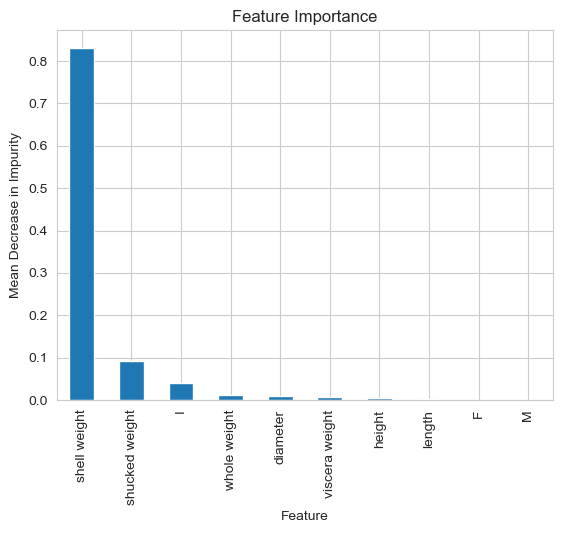

In [120]:
forest_importances = pd.Series(
    rfr_1.feature_importances_,
    abalone.drop('rings', axis=1).columns
)

forest_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Mean Decrease in Impurity')
plt.show()

From the importance plot above we see that `shell weight` is clearly the most important feature and that weight in general is considered very important in determining abalone age via the number of rings (i.e., of the four most important features, weight is a component of three - 75%). Interestingly, the Infant `I` feature is also of high importance. This is likely due to Infant abalone having a small number of rings due to the relationship between rings and age (i.e., the older the abalone, the greater the number of rings). Below we can see that only two features (`shucked weight` and `shell weight`) achieve an importance greater than the 0.05 threshold and that the combined importance of these two features is approx. 0.92.

In [121]:
imp_idx = forest_importances > 0.05
forest_importances[imp_idx]

shucked weight    0.091436
shell weight      0.831086
dtype: float64

In [122]:
forest_importances[imp_idx].sum()

0.9225219531449466

Before continuing the regression modelling, we must reduce the dimension of our data by extracting the features that hurdle the chosen 0.05 threshold of importance.

In [123]:
X_train_reduced = X_train[:, imp_idx]
X_test_reduced = X_test[:, imp_idx]

Now we can repeat the training and prediction processes on the reduced-dimensional data. We expect to see a slight increase of RMSE for the reduced-dimensional data. In many real applications, the feature dimension of the data may be reduced drastically with only a slight increase in the prediction error. We won’t see this in this small dataset as the feature dimension is already quite small.

In [124]:
rfr_reduced = RandomForestRegressor(
    n_estimators=500,  max_depth=5, min_samples_leaf=50, random_state=123
)
rfr_reduced.fit(X_train_reduced, y_train)

print('Reduced Dimension RandomForestRegressor RMSE:',
    mean_squared_error(y_test, rfr_reduced.predict(X_test_reduced).round(), squared=False)
)

Reduced Dimension RandomForestRegressor RMSE: 1.5789024232645958


As expected, we see that the __RMSE__ has increased from approx. 1.51 on the full dimensional data to approx. 1.58 on the reduced dimensional data. Before investigating another model type, we will compare the performance of the two Random Forest regressors through plots of the actual vs. predicted ring values, and the distribution of the errors (i.e., the difference in predicted and actual value).

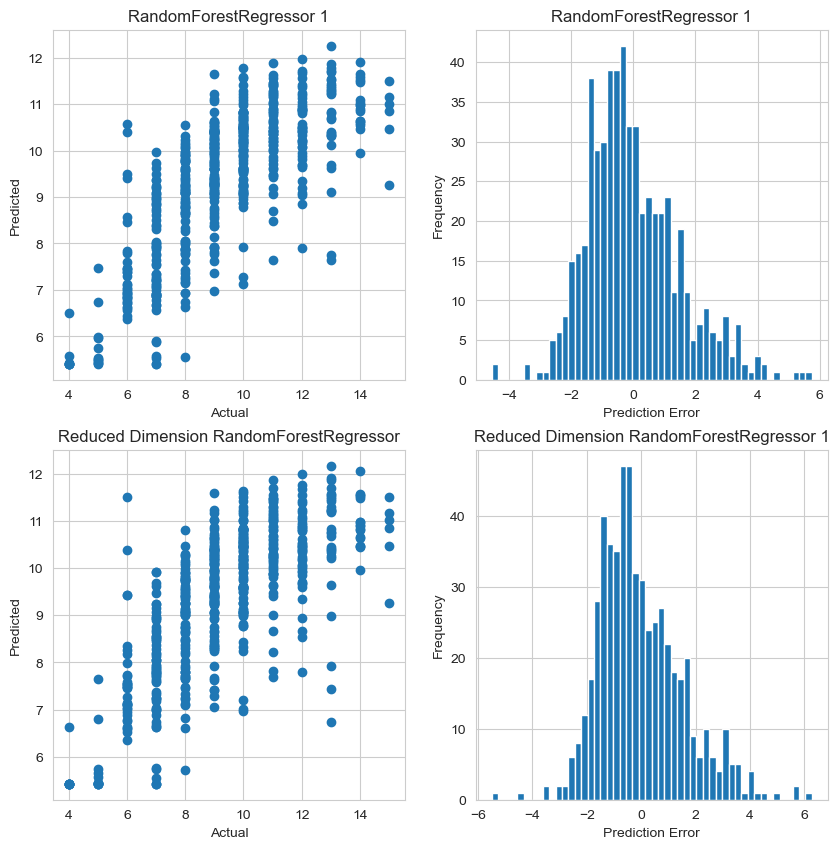

In [125]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.scatter(y_test, rfr_1.predict(X_test))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RandomForestRegressor 1')
plt.subplot(2,2,2)
rfr_1_err = pd.Series(y_test - rfr_1.predict(X_test))
rfr_1_err.hist(bins = 50)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('RandomForestRegressor 1');

plt.subplot(2,2,3)
plt.scatter(y_test, rfr_reduced.predict(X_test_reduced))
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Reduced Dimension RandomForestRegressor')
plt.subplot(2,2,4)
rfr_red_err = pd.Series(y_test - rfr_reduced.predict(X_test_reduced))
rfr_red_err.hist(bins = 50)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Reduced Dimension RandomForestRegressor 1');

With respect to the above scatter plots, i.e., acutal vs predicted ring values, we can see that both random forest regression models have a very similar pattern with only a slight variation in position of a number of the points. Of note though is the slightly greater scale found on the histogram of errors for the reduced dimension random forest regressor (i.e., the left tail of the histogram is longer). This indicates a slightly greater propensity for this regression model to make larger scale erorr in this direction. Apart from this observation, the erorr distrubtions are approximately symmetric and very similar. To investigate the effect of the number of rings on the errors made by the regression model we can collect the statistical descriptors for each ring value and display them  for our best model (i.e., Random Forest Regressor 1 with hyperparameter values `max depth = 5`, `min samples leaf = 50`).

In [126]:
rfr_1_err_metrics = pd.DataFrame({
    'error': rfr_1_err, 'rings': y_test
}).groupby('rings').describe()
rfr_1_err_metrics.sort_values(by=[('error', 'mean')], ascending=False)

error                                                              \
       count      mean       std       min       25%       50%       75%   
rings                                                                      
15       6.0  4.292936  0.788937  3.499415  3.882107  4.068087  4.433331   
14      17.0  3.012319  0.510362  2.084117  2.522763  3.029677  3.368069   
13      29.0  2.300061  1.113798  0.740871  1.570520  2.166622  2.670939   
12      45.0  1.586482  0.838889  0.018381  1.071142  1.538236  2.048290   
11      59.0  0.569304  0.832277 -0.882258 -0.036500  0.572437  0.970909   
10     103.0 -0.057056  0.822735 -1.766759 -0.561220 -0.203981  0.437264   
9      106.0 -0.612214  0.869609 -2.640175 -1.264334 -0.688246 -0.191999   
7       66.0 -0.790565  1.151426 -2.969132 -1.842930 -0.761237  0.065078   
8       80.0 -0.808579  1.040819 -2.549090 -1.618104 -1.081719  0.001835   
5       12.0 -0.848611  0.638446 -2.460878 -0.975827 -0.522356 -0.454805   
6       35.0 -1.451731  1.057084 -4.566856 -1.532846 -1.048683 -0.830007   
4        8.0 -1.569998  0.383995 -2.508693 -1.466879 -1.408200 -1.408200   

                 
            max  
rings            
15     5.746836  
14     4.048262  
13     5.349710  
12     4.102037  
11     3.359972  
10     2.867472  
9      2.028569  
7      1.591800  
8      2.439567  
5     -0.408200  
6     -0.377937  
4     -1.408200

From the error metrics above we see that the largest mean error (approx. 4.3) occurs for ring values of 15 - the largest ring value in the data. Additionally, we note this ring value (15) is the lowest occuring value in the data. Furthermore, we see that high ring values are consitent with high mean error, i.e., the largest mean absolute errors occur in sequence, from highest to lowest, for the largest ring values. Examining the frequency of ring values in the training data (see histogram below) we see that the lowest absolute mean error (approx. 0.06) corresponds to the ring value with the highest training density, i.e., 10. From these observations, we can conclude that there exists a negative influence on the average error with respect to large ring values and that ring values occuring frequently in the data also have a positive affect on average prediction error, albeit the size of the effect is lesser so than in the former circumstance.

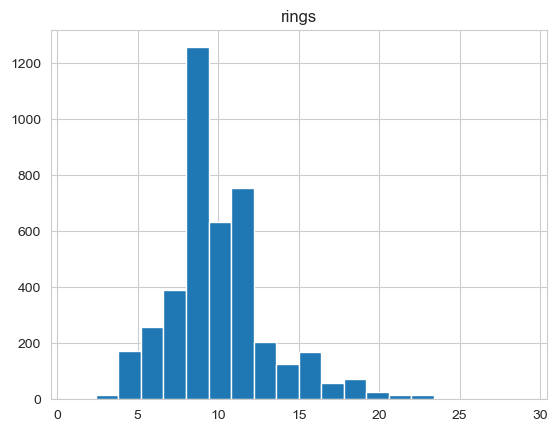

In [127]:
abalone[['rings']].hist(bins=20);

To conlude our regression modelling of the abalone data, we shall implement a Bagging regressor with 500 SVM regressors as the base estimators. As before, we will choose reasonable hyperparameter values manually for the SVM regressors. In this case, on the grounds of efficiency and simplicity we will restrict the base SVM regressor to a polynomial kernel of third degree. We will train the Bagging regressor using the full dimensional training set and test it using the full dimensional test set and report the __RMSE__ of the predictions for the test set.

In [128]:
from sklearn.ensemble import BaggingRegressor

svr = SVR(kernel='poly', degree=3)
svr_bag = BaggingRegressor(svr, n_estimators=500, random_state=123)
svr_bag.fit(X_train, y_train)

preds = svr_bag.predict(X_test)

print(svr_bag.__class__.__name__, 'RMSE: ', mean_squared_error(y_test, preds.round(), squared=False))

BaggingRegressor RMSE:  1.5472533512202167


As before, we can illustrate in a plot the predicted ring values versus the ground truth ring values of all the test instances along with the distribution of such errors via a histogram of the differences between actual and predicted ring values.

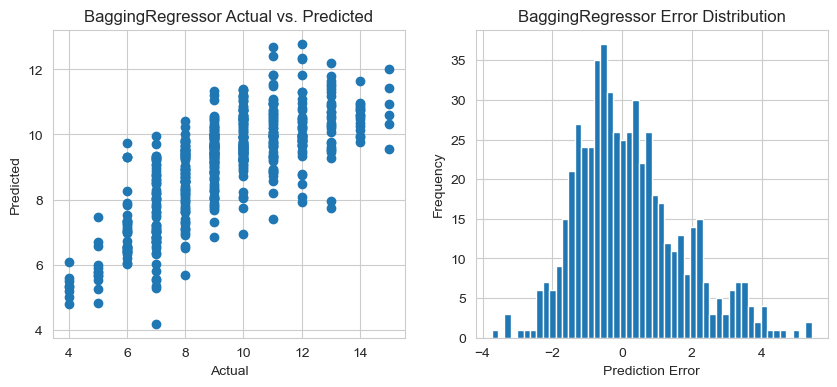

In [129]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_test, preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('BaggingRegressor Actual vs. Predicted')
plt.subplot(1,2,2)
svr_bag_err = pd.Series(y_test - preds)
svr_bag_err.hist(bins = 50)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('BaggingRegressor Error Distribution');

We again see a similar pattern in the scatterplot of actual vs. predicted ring values as with the previous random forrest regressor. The same degree of similarity is also present in the histogram of errors. Finally, we can compare the performance of our optimal Random Forest regressor with the Bagging regressor by examining the error statistics as before.

In [130]:
svr_bag_err_metrics = pd.DataFrame({
    'error': svr_bag_err, 'rings': y_test
}).groupby('rings').describe()
svr_bag_err_metrics.sort_values(by=[('error', 'mean')], ascending=False)

error                                                              \
       count      mean       std       min       25%       50%       75%   
rings                                                                      
15       6.0  4.191215  0.861997  2.979082  3.697488  4.230487  4.618957   
14      17.0  3.449061  0.460813  2.364152  3.188878  3.407245  3.733486   
13      29.0  2.600377  1.049261  0.816462  1.820398  2.492321  3.260306   
12      45.0  1.851633  1.000967 -0.787651  1.485388  2.029897  2.308688   
11      59.0  0.924119  0.994737 -1.701325  0.355772  1.013006  1.581874   
10     103.0  0.155625  0.807205 -1.399638 -0.478378  0.297493  0.620620   
9      106.0 -0.347951  0.825649 -2.347161 -0.902317 -0.449597  0.147018   
8       80.0 -0.601841  0.975047 -2.418769 -1.400509 -0.688817  0.040299   
7       66.0 -0.635173  1.232658 -2.952772 -1.627190 -0.627820  0.180114   
5       12.0 -0.926572  0.699112 -2.460255 -1.138741 -0.763772 -0.626869   
6       35.0 -1.184595  0.971165 -3.741815 -1.339248 -1.020953 -0.486291   
4        8.0 -1.356375  0.388754 -2.079881 -1.527848 -1.326530 -1.145685   

                 
            max  
rings            
15     5.438963  
14     4.229289  
13     5.262815  
12     4.073204  
11     3.606409  
10     3.059748  
9      2.151561  
8      2.309110  
7      2.811575  
5      0.171139  
6     -0.021095  
4     -0.803840

Again, the error statsitics exhibit great similarity between the two regression models (i.e., the Bagging Regressor above, and the Random Forest Regressor below). Apart from the similarity in correspondence between high ring values and larger mean errors, we see that the Bagging Regressor (above) has slightly lesser error on these large ring values than does the Random Forest Regressor (below). On the other hand, this somewhat greater mean error on the larger values is overwhelmed by the much lower mean error in the most frequent ring value of 10 (i.e., mean error of approx. 0.15 for the Bagging Regressor as opposed to mean absolute error of approx. 0.05 for the Random Forrest Regressor). 

In [131]:
rfr_1_err_metrics.sort_values(by=[('error', 'mean')], ascending=False)

error                                                              \
       count      mean       std       min       25%       50%       75%   
rings                                                                      
15       6.0  4.292936  0.788937  3.499415  3.882107  4.068087  4.433331   
14      17.0  3.012319  0.510362  2.084117  2.522763  3.029677  3.368069   
13      29.0  2.300061  1.113798  0.740871  1.570520  2.166622  2.670939   
12      45.0  1.586482  0.838889  0.018381  1.071142  1.538236  2.048290   
11      59.0  0.569304  0.832277 -0.882258 -0.036500  0.572437  0.970909   
10     103.0 -0.057056  0.822735 -1.766759 -0.561220 -0.203981  0.437264   
9      106.0 -0.612214  0.869609 -2.640175 -1.264334 -0.688246 -0.191999   
7       66.0 -0.790565  1.151426 -2.969132 -1.842930 -0.761237  0.065078   
8       80.0 -0.808579  1.040819 -2.549090 -1.618104 -1.081719  0.001835   
5       12.0 -0.848611  0.638446 -2.460878 -0.975827 -0.522356 -0.454805   
6       35.0 -1.451731  1.057084 -4.566856 -1.532846 -1.048683 -0.830007   
4        8.0 -1.569998  0.383995 -2.508693 -1.466879 -1.408200 -1.408200   

                 
            max  
rings            
15     5.746836  
14     4.048262  
13     5.349710  
12     4.102037  
11     3.359972  
10     2.867472  
9      2.028569  
7      1.591800  
8      2.439567  
5     -0.408200  
6     -0.377937  
4     -1.408200

Finally, we conclude our analysis of the various regression models recalling that, in general, a simple model is to be preferred over a complex model when all other considerations are equal. In our case, the simple model is the Random Forrest Regressor with hyperparameter values `max depth = 5` and `min samples leaf = 50` (i.e., `Random Forrest Regressor 1`). Furthermore, as can be seen by recalling the __RMSE__ metrics for the various regression models (see below), it is clear that this 'simple' model has lower average error than the more complex model (i.e., the `SVR Bagging Regressor`) and the reduced dimension model (i.e., `Reduced Dimension Random Forest Regressor`). We therefore conclude that for our purposes the simple model is superior to the more complex model under the framework we have investigated for predicting the age of abalone from the proxy measure of number of rings.

In [132]:
model_comp = pd.DataFrame({
    'Model': [
        'Random Forest Regressor 1', 
        'Reduced Dimension Random Forest Regressor',
        'SVR Bagging Regressor'
    ],
    'RMSE': [
        mean_squared_error(y_test, rfr_1.predict(X_test).round(), squared=False),
        mean_squared_error(y_test, rfr_reduced.predict(X_test_reduced).round(), squared=False),
        mean_squared_error(y_test, preds.round(), squared=False)
    ]
}).sort_values(by='RMSE', ascending=True)

model_comp

,Model,RMSE
0,Random Forest Regressor 1,1.510856
2,SVR Bagging Regressor,1.547253
1,Reduced Dimension Random Forest Regressor,1.578902
